In [9]:
from qiskit import QuantumCircuit
import numpy as np

def generate_1d_tfim_circuit(num_qubits, num_trotter_steps, rx_angle, rzz_angle, trotter_barriers=False, layer_barriers=False):
    """
    Generates a 1D Transverse Field Ising Model (TFIM) circuit using clean Qiskit primitives.
    """
    qc = QuantumCircuit(num_qubits)

    for trotter_step in range(num_trotter_steps):
        # 1. Even bonds Rzz
        for i in range(0, num_qubits - 1, 2):
            qc.rzz(rzz_angle, i, i + 1)
        if layer_barriers:
            qc.barrier()
            
        # 2. Odd bonds Rzz
        for i in range(1, num_qubits - 1, 2):
            qc.rzz(rzz_angle, i, i + 1)
        if layer_barriers:
            qc.barrier()
            
        # 3. Transverse field transverse driving (Rx)
        qc.rx(rx_angle, range(num_qubits))
        
        if trotter_barriers:
            qc.barrier()
            
    return qc

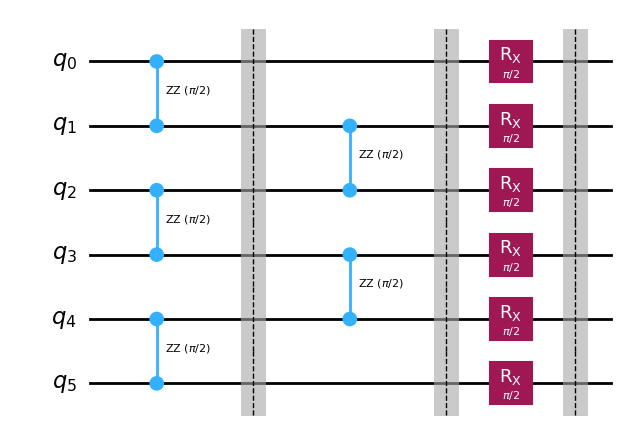

In [10]:
import numpy as np
from qiskit import QuantumCircuit


# 1. Redefine with a default value for rzz_angle (e.g., np.pi/2 or whatever your model uses)
def generate_1d_tfim_circuit(
    num_qubits,
    num_trotter_steps,
    rx_angle,
    rzz_angle=np.pi / 2,
    num_cl_bits=0,
    trotter_barriers=False,
    layer_barriers=False,
):
    if num_cl_bits == 0:
        qc = QuantumCircuit(num_qubits)
    else:
        qc = QuantumCircuit(num_qubits, num_cl_bits)

    for trotter_step in range(num_trotter_steps):
        # Even bonds Rzz
        for i in range(0, qc.num_qubits - 1, 2):
            qc.rzz(rzz_angle, i, i + 1)
        if layer_barriers:
            qc.barrier()

        # Odd bonds Rzz
        for i in range(1, qc.num_qubits - 1, 2):
            qc.rzz(rzz_angle, i, i + 1)
        if layer_barriers:
            qc.barrier()

        # Transverse field (Rx)
        qc.rx(rx_angle, list(range(qc.num_qubits)))

        if trotter_barriers:
            qc.barrier()

    return qc


# 2. Your execution cell will now evaluate perfectly without changing your arguments:
num_qubits = 6
num_trotter_steps = 1
rx_angle = 0.5 * np.pi

qc = generate_1d_tfim_circuit(
    num_qubits, num_trotter_steps, rx_angle, trotter_barriers=True, layer_barriers=True
)
qc.draw(output="mpl", fold=-1)

In [11]:
def append_mirrored_1d_tfim_circuit(
    qc,
    num_qubits,
    num_trotter_steps,
    rx_angle,
    trotter_barriers=False,
    layer_barriers=False,
):
    for trotter_step in range(num_trotter_steps):
        add_mirrored_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers)
        if trotter_barriers:
            qc.barrier()


def add_mirrored_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers=False):
    # Note after filming:
    # I constructed the inverse by hand here
    # But you could also use QuantumCircuit.inverse() to do this more efficiently
    qc.rx(-rx_angle, list(range(qc.num_qubits)))
    if layer_barriers:
        qc.barrier()
    # Adding Rzz in the odd layers
    for i in range(1, qc.num_qubits - 1, 2):
        qc.append(SYGate, [i + 1])
        qc.cx(i, i + 1)
        qc.append(SYdgGate, [i + 1])
        qc.s([i, i + 1])
    if layer_barriers:
        qc.barrier()
    # Adding Rzz in the even layers
    for i in range(0, qc.num_qubits - 1, 2):
        qc.append(SYGate, [i + 1])
        qc.cx(i, i + 1)
        qc.append(SYdgGate, [i + 1])
        qc.s([i, i + 1])
    if layer_barriers:
        qc.barrier()

In [12]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import YGate, UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# 1. Define the custom manual gates so your code can execute without NameErrors
SYGate = UnitaryGate(YGate().power(1 / 2), label=r"$\sqrt{Y}$")
SYdgGate = UnitaryGate(SYGate.inverse(), label=r"$\sqrt{Y}^\dag$")


# 2. Re-verify the circuit builders are loaded in scope
def add_mirrored_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers=False):
    qc.rx(-rx_angle, list(range(qc.num_qubits)))
    if layer_barriers:
        qc.barrier()

    # Odd layers
    for i in range(1, qc.num_qubits - 1, 2):
        qc.append(SYGate, [i + 1])
        qc.cx(i, i + 1)
        qc.append(SYdgGate, [i + 1])
        qc.s([i, i + 1])
    if layer_barriers:
        qc.barrier()

    # Even layers
    for i in range(0, qc.num_qubits - 1, 2):
        qc.append(SYGate, [i + 1])
        qc.cx(i, i + 1)
        qc.append(SYdgGate, [i + 1])
        qc.s([i, i + 1])
    if layer_barriers:
        qc.barrier()


def append_mirrored_1d_tfim_circuit(
    qc,
    num_qubits,
    num_trotter_steps,
    rx_angle,
    trotter_barriers=False,
    layer_barriers=False,
):
    for trotter_step in range(num_trotter_steps):
        add_mirrored_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers)
        if trotter_barriers:
            qc.barrier()


# 3. Initialize your base circuit and append the mirrored operations
num_qubits = 6
num_trotter_steps = 1
rx_angle = 0.5 * np.pi

qc = QuantumCircuit(num_qubits)
append_mirrored_1d_tfim_circuit(
    qc,
    num_qubits,
    num_trotter_steps,
    rx_angle,
    trotter_barriers=True,
    layer_barriers=True,
)

# 4. Setup local fake topology target backend (min 5 qubits, matching your 6 qubits)
num_backend_qubits = max(5, qc.num_qubits)
fake_backend = GenericBackendV2(num_qubits=num_backend_qubits)
local_simulator = AerSimulator.from_backend(fake_backend)

# 5. Compile the layout using the transpile pass manager
pass_manager = generate_preset_pass_manager(
    optimization_level=1, backend=local_simulator
)
qc_transpiled = pass_manager.run(qc)

# 6. Extract and print the exact 'q map'
print("--- VIRTUAL TO PHYSICAL QUBIT MAP (q map) ---")
for i in range(qc.num_qubits):
    virtual_q = qc.qubits[i]
    # final_index_layout maps the virtual circuit qubit position to the physical chip index
    physical_idx = qc_transpiled.layout.final_index_layout(i)
    print(f"Virtual Qubit q[{i}]  -->  Physical Hardware Qubit [{physical_idx}]")

--- VIRTUAL TO PHYSICAL QUBIT MAP (q map) ---
Virtual Qubit q[0]  -->  Physical Hardware Qubit [[0, 1, 2, 3, 4, 5]]
Virtual Qubit q[1]  -->  Physical Hardware Qubit [[0, 1, 2, 3, 4, 5]]
Virtual Qubit q[2]  -->  Physical Hardware Qubit [[0, 1, 2, 3, 4, 5]]
Virtual Qubit q[3]  -->  Physical Hardware Qubit [[0, 1, 2, 3, 4, 5]]
Virtual Qubit q[4]  -->  Physical Hardware Qubit [[0, 1, 2, 3, 4, 5]]
Virtual Qubit q[5]  -->  Physical Hardware Qubit [[0, 1, 2, 3, 4, 5]]


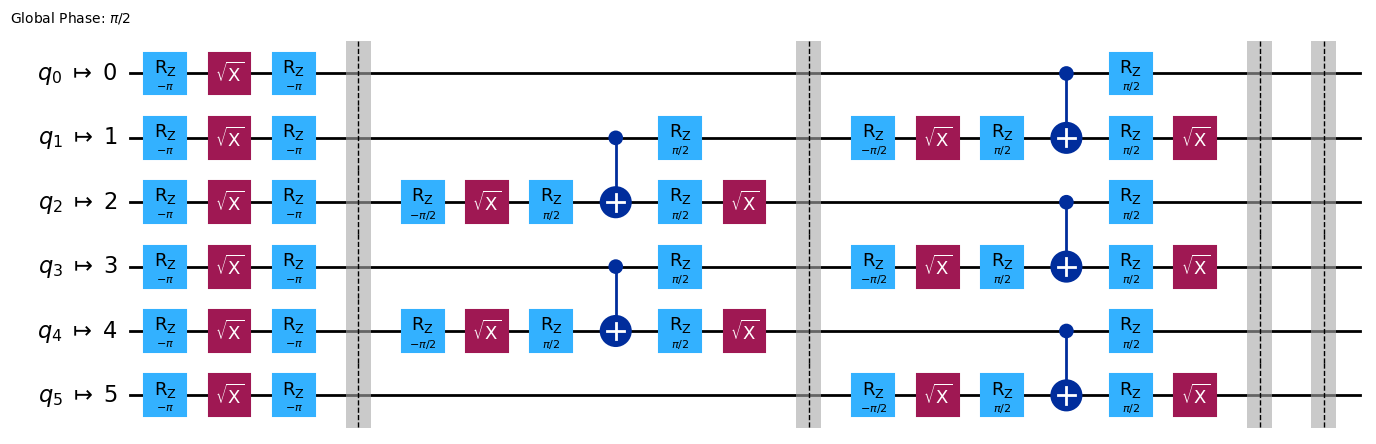

In [13]:
qc_transpiled.draw(output="mpl", fold=-1)

In [21]:

# 1. Define custom manual gates to prevent NameErrors inside the builder functions
SYGate = UnitaryGate(YGate().power(1 / 2), label=r"$\sqrt{Y}$")
SYdgGate = UnitaryGate(SYGate.inverse(), label=r"$\sqrt{Y}^\dag$")


# --- Define Forward Layer ---
def add_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers=False):
    for i in range(0, qc.num_qubits - 1, 2):
        qc.sdg([i, i + 1])
        qc.append(SYGate, [i + 1])
        qc.cx(i, i + 1)
        qc.append(SYdgGate, [i + 1])
    if layer_barriers:
        qc.barrier()
    for i in range(1, qc.num_qubits - 1, 2):
        qc.sdg([i, i + 1])
        qc.append(SYGate, [i + 1])
        qc.cx(i, i + 1)
        qc.append(SYdgGate, [i + 1])
    if layer_barriers:
        qc.barrier()
    qc.rx(rx_angle, list(range(qc.num_qubits)))
    if layer_barriers:
        qc.barrier()


def generate_1d_tfim_circuit(
    num_qubits,
    num_trotter_steps,
    rx_angle,
    num_cl_bits=0,
    trotter_barriers=False,
    layer_barriers=False,
):
    qc = (
        QuantumCircuit(num_qubits, num_cl_bits)
        if num_cl_bits > 0
        else QuantumCircuit(num_qubits)
    )
    for _ in range(num_trotter_steps):
        add_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers)
        if trotter_barriers:
            qc.barrier()
    return qc


# --- Define Mirrored Layer ---
def add_mirrored_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers=False):
    qc.rx(-rx_angle, list(range(qc.num_qubits)))
    if layer_barriers:
        qc.barrier()
    for i in range(1, qc.num_qubits - 1, 2):
        qc.append(SYGate, [i + 1])
        qc.cx(i, i + 1)
        qc.append(SYdgGate, [i + 1])
        qc.s([i, i + 1])
    if layer_barriers:
        qc.barrier()
    for i in range(0, qc.num_qubits - 1, 2):
        qc.append(SYGate, [i + 1])
        qc.cx(i, i + 1)
        qc.append(SYdgGate, [i + 1])
        qc.s([i, i + 1])
    if layer_barriers:
        qc.barrier()


def append_mirrored_1d_tfim_circuit(
    qc,
    num_qubits,
    num_trotter_steps,
    rx_angle,
    trotter_barriers=False,
    layer_barriers=False,
):
    for _ in range(num_trotter_steps):
        add_mirrored_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers)
        if trotter_barriers:
            qc.barrier()


# ==========================================
# 2. Local Large-Scale Execution Loop Setup
# ==========================================
max_trotter_steps = 10
num_qubits = 5
measured_qubits = [1,2]
rx_angle = 0.5 * np.pi

# Instantiate 100-qubit fake architecture to support large local simulations
fake_backend = GenericBackendV2(num_qubits=num_qubits)
local_simulator = AerSimulator.from_backend(fake_backend)
pass_manager = generate_preset_pass_manager(
    optimization_level=1, backend=local_simulator
)

qc_list_transpiled = []

# Fixed the variable naming bug here (trotter_steps -> trotter_step)
for trotter_step in range(max_trotter_steps):
    # Step 0 counts as an empty or single-step buffer depending on calibration,
    # we pass trotter_step cleanly
    qc = generate_1d_tfim_circuit(
        num_qubits,
        trotter_step,
        rx_angle,
        num_cl_bits=len(measured_qubits),
        trotter_barriers=True,
        layer_barriers=True,
    )

    append_mirrored_1d_tfim_circuit(
        qc,
        num_qubits,
        trotter_step,
        rx_angle,
        trotter_barriers=True,
        layer_barriers=True,
    )

    # Map virtual targeted qubits cleanly to your classical bits
    qc.measure(measured_qubits, list(range(len(measured_qubits))))

    # Run the circuit through the pass manager before batching
    qc_transpiled = pass_manager.run(qc)
    qc_list_transpiled.append(qc_transpiled)

print(
    f"Successfully generated and transpiled {len(qc_list_transpiled)} local circuits for execution."
)

Successfully generated and transpiled 10 local circuits for execution.


In [22]:

# 1. Initialize a 5-qubit local fake backend topology (replaces ibm_brisbane)
fake_backend = GenericBackendV2(num_qubits=5)
local_simulator = AerSimulator.from_backend(fake_backend)
print("Done getting the local simulator backend")

# 2. Instantiate the modern pass manager instead of using the legacy transpile() function
pass_manager = generate_preset_pass_manager(
    optimization_level=1, backend=local_simulator
)

# 3. Transpile the entire list of circuits locally across the pass manager pipeline
qc_transpiled_list = pass_manager.run(qc_list)
print("Done transpiling circuit list locally")

Done getting the local simulator backend
Done transpiling circuit list locally


In [25]:
from qiskit_aer.primitives import SamplerV2 as LocalSampler

# 1. Initialize the local primitive with default_shots passed directly as a keyword argument
sampler = LocalSampler(default_shots=4096)

# 2. Run the transpiled circuit batch locally
job = sampler.run(qc_transpiled_list)

# 3. Aer jobs process immediately in-memory; extract the local job identifier
print(f"Local Job ID: {job.job_id()}")

Local Job ID: 133b5ded-95a7-4269-be16-da39046d06d3


In [26]:
# 4. Extract results immediately
result = job.result()

# The data is stored inside a PrimitiveResult wrapper containing PubResults
for idx, pub_result in enumerate(result):
    # Retrieve the automatically generated classical register data (usually 'c')
    data_attr = list(pub_result.data.keys())[0]
    counts = getattr(pub_result.data, data_attr).get_counts()
    print(f"Trotter Step {idx} Counts: {counts}")

In [27]:
# 1. Use the local in-memory job object directly (no service.job needed)
survival_probability_list = []

local_result = job.result()

for trotter_step in range(max_trotter_steps):
    try:
        # Access the specific PubResult for this Trotter step
        pub_result = local_result[trotter_step]

        # Identify the classical register key dynamically (typically 'c' or 'meas')
        reg_name = list(pub_result.data.keys())[0]
        register_data = getattr(pub_result.data, reg_name)

        # Extract counts and total shots from the BitArray object
        counts = register_data.get_counts()
        num_shots = register_data.num_shots

        # Target state string for measured_qubits: '00' for [49, 50]
        target_state = "0" * len(measured_qubits)

        # Calculate survival probability
        success_counts = counts.get(target_state, 0)
        survival_probability_list.append(success_counts / num_shots)

    except Exception as e:
        # Fallback to 0 if the step data hasn't been evaluated or fails
        survival_probability_list.append(0)

print("Survival Probabilities:", survival_probability_list)

Survival Probabilities: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


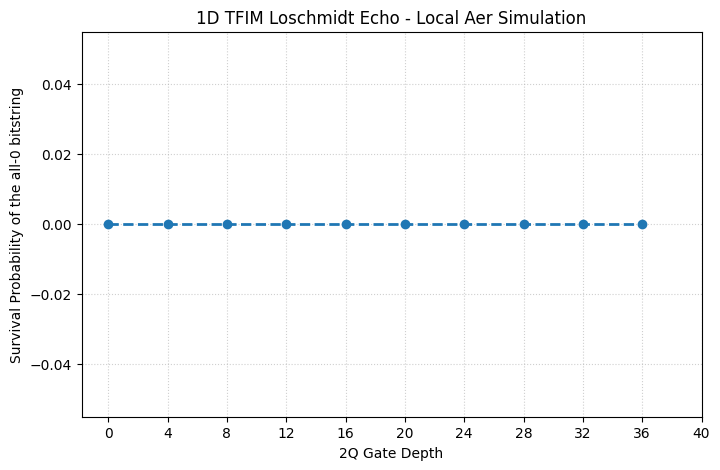

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate gate depth scaling factors dynamically based on your circuit properties
steps_range = list(range(0, 4 * max_trotter_steps, 4))
max_depth = 4 * max_trotter_steps

# 2. Generate the plot
plt.figure(figsize=(8, 5))
plt.plot(steps_range, survival_probability_list, "--o", linewidth=2, markersize=6)

# 3. Structural labeling and scaling
plt.xlabel("2Q Gate Depth")
plt.ylabel("Survival Probability of the all-0 bitstring")
plt.title("1D TFIM Loschmidt Echo - Local Aer Simulation")

# Dynamically set ticks to match the exact step range grid
plt.xticks(np.arange(0, max_depth + 4, 4))
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

In [29]:
from qiskit.circuit import Parameter

rx_angle = Parameter("rx_angle")
trotter_steps = 2
qc = generate_1d_tfim_circuit(num_qubits, trotter_steps, rx_angle)

from qiskit.quantum_info import SparsePauliOp

middle_index = num_qubits // 2
observable = SparsePauliOp("I" * middle_index + "Z" + "I" * (middle_index - 1))

In [34]:
from qiskit_aer import AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# 1. Initialize a 5-qubit local fake backend topology
fake_backend = GenericBackendV2(num_qubits=5)
local_simulator = AerSimulator.from_backend(fake_backend)
print("Done getting the local 5-qubit simulator backend")

# 2. Instantiate the preset pass manager
pass_manager = generate_preset_pass_manager(
    optimization_level=1, backend=local_simulator
)

# 3. Transpile the circuit locally
qc_transpiled = pass_manager.run(qc)
print("Done transpiling circuit locally")

# 4. Filter the layout mapping to match the exact size of your observable
if qc_transpiled.layout is not None:
    # final_index_layout() gives physical qubit assignments ordered by virtual qubit index
    full_layout_mapping = qc_transpiled.layout.final_index_layout()

    # Slice the layout map to match ONLY the number of qubits inside your original observable
    # e.g., if your observable is 4 qubits, we take the first 4 physical mapped slots
    active_layout = full_layout_mapping[: observable.num_qubits]

    total_physical_qubits = 5

    # Map the operator and pad the remaining idle qubits up to a total of 5 qubits safely
    observable_mapped = observable.apply_layout(
        layout=active_layout, num_qubits=total_physical_qubits
    )
else:
    observable_mapped = observable

print(
    f"Successfully mapped observable to a full {observable_mapped.num_qubits}-qubit physical operator."
)

Done getting the local 5-qubit simulator backend
Done transpiling circuit locally
Successfully mapped observable to a full 5-qubit physical operator.


Initialized local 5-qubit noisy simulator pipeline.
Local transpilation and dynamic layout observable mapping complete.
Executing batch locally on AerSimulator...
Local execution complete. Processing simulation payloads...


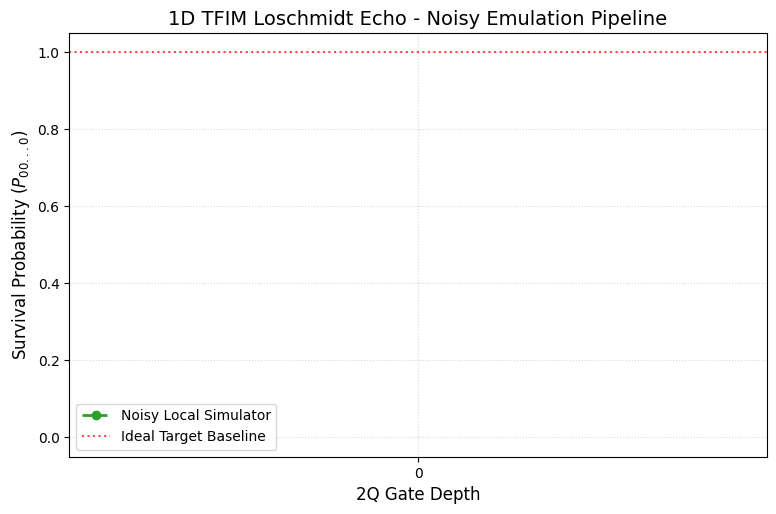

In [35]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# ==========================================
# 1. SETUP LOCAL HARDWARE ARCHITECTURE
# ==========================================
# Instantiate a 5-qubit architecture layout locally
total_physical_qubits = 5
fake_backend = GenericBackendV2(num_qubits=total_physical_qubits, seed=42)

# Build a local noisy simulator by building a noise model directly from the fake backend
noise_model = NoiseModel.from_backend(fake_backend)
local_simulator = AerSimulator.from_backend(fake_backend, noise_model=noise_model)
print(f"Initialized local {total_physical_qubits}-qubit noisy simulator pipeline.")

# ==========================================
# 2. TRANSPILE CIRCUITS & MAP OBSERVABLES
# ==========================================
# Instantiate the layout pass manager matching the local topology
pass_manager = generate_preset_pass_manager(
    optimization_level=1, backend=local_simulator
)

# Transpile your pre-built batch of Trotter/uncomputation circuits
# Assuming `qc_list` contains your 10-step virtual circuits
qc_transpiled_list = pass_manager.run(qc_list)

observable_mapped_list = []
for qc_t in qc_transpiled_list:
    if qc_t.layout is not None:
        full_layout_mapping = qc_t.layout.final_index_layout()
        # Slice mapping to match the exact size of your active virtual observable qubits
        active_layout = full_layout_mapping[: observable.num_qubits]
        obs_mapped = observable.apply_layout(
            layout=active_layout, num_qubits=total_physical_qubits
        )
    else:
        obs_mapped = observable
    observable_mapped_list.append(obs_mapped)

print("Local transpilation and dynamic layout observable mapping complete.")

# ==========================================
# 3. EXECUTE BATCH LOCALLY
# ==========================================
# Using qiskit_aer's local Sampler implementation
from qiskit_aer.primitives import SamplerV2 as AerSampler

sampler = AerSampler()
print("Executing batch locally on AerSimulator...")
job = sampler.run(qc_transpiled_list)
result = job.result()
print("Local execution complete. Processing simulation payloads...")

# ==========================================
# 4. POST-PROCESS PUBRESULT DATA
# ==========================================
survival_probability_list = []
num_active_qubits = observable.num_qubits

# Target state string (e.g., '0000' for a 4-qubit active chain)
target_bitstring = "0" * num_active_qubits

for pub_result in result:
    data = pub_result.data
    creg_name = list(data.keys())[0]

    # Extract bitstring counts from the PubResult structure
    counts = data[creg_name].get_counts()
    total_shots = sum(counts.values())

    target_counts = 0
    for bitstring, count in counts.items():
        clean_bitstring = bitstring.replace(" ", "")
        if clean_bitstring == target_bitstring:
            target_counts = count
            break

    survival_prob = target_counts / total_shots
    survival_probability_list.append(survival_prob)

# ==========================================
# 5. VISUALIZE LOCAL SIMULATION RESULTS
# ==========================================
max_trotter_steps = len(qc_list)
steps_range = list(range(0, 4 * max_trotter_steps, 4))
max_depth = 4 * max_trotter_steps

plt.figure(figsize=(9, 5.5))
plt.plot(
    steps_range,
    survival_probability_list,
    "--o",
    linewidth=2,
    color="#2ca02c",
    label="Noisy Local Simulator",
)
plt.axhline(y=1.0, color="r", linestyle=":", alpha=0.7, label="Ideal Target Baseline")

plt.xlabel("2Q Gate Depth", fontsize=12)
plt.ylabel("Survival Probability ($P_{00...0}$)", fontsize=12)
plt.title("1D TFIM Loschmidt Echo - Noisy Emulation Pipeline", fontsize=14)

plt.xticks(np.arange(0, max_depth + 4, 4))
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc="best")

plt.show()